# 📦 Análise de Vendas Nacionais — Loja ShopOnline


Análise de dados de pedidos de e-commerce realizados em todo o território nacional, cobrindo o período de **janeiro/2021 a maio/2026**.

Notebook desenvolvido para fins de portfólio em Análise de Dados, seguindo a metodologia **SAPE** (Situação, Análise, Plano e Execução).

## 1. Problema de Negócio

A ShopOnline é uma loja virtual que vende para todo o Brasil. Nos últimos meses, a diretoria notou oscilações no número de pedidos e no faturamento, e quer enxergar com clareza o que está acontecendo com o negócio antes de planejar o próximo trimestre.

A diretoria pediu uma análise dos pedidos para responder quatro perguntas:

1. Como está a saúde do negócio, de forma geral?
2. O que explica os períodos em que o faturamento sobe ou cai?
3. Qual a previsão de faturamento para o próximo mês (junho/2026)?
4. Quais ações podem ser recomendadas para impulsionar ainda mais as vendas?

## 2. Ferramentas Utilizadas

**Ferramentas para Análise de Dados**
- Python (pandas, numpy)
- Visualização de dados (matplotlib, seaborn)
- Estatística descritiva e correlação
- Regressão Linear e decomposição de Série Temporal (scikit-learn)

**Habilidades e Abordagem**
- Pensamento crítico e resolução de problemas para estruturar a análise e validar hipóteses de negócio com dados.

## 3. Descrição dos Dados

| Campo | Descrição |
|---|---|
| `Cidade` | Cidade onde o pedido foi realizado |
| `Estado` | UF da cidade do pedido |
| `Data` | Data do pedido |
| `Hora` | Horário do pedido |
| `Total` | Valor total do pedido (R$) |
| `Status Pedido` | Status do pedido |
| `Qtd. Itens` | Quantidade de itens (linhas) distintos no pedido |
| `Qtd. Unidades` | Quantidade total de unidades compradas no pedido |

### 3.1 Premissas Assumidas
- Cada linha do arquivo já representa **um pedido único** (não há granularidade de item de pedido).
- Todos os registros têm status **"Aprovado"**, ou seja, a base reflete apenas vendas concluídas — não há, nesta base, visão sobre pedidos cancelados ou recusados.
- Valores monetários estavam no formato brasileiro (`1.234,56`) e foram convertidos para float padrão antes da análise.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

COLOR_MAIN = '#2E5077'
COLOR_ACC  = '#F39C12'

## 4. Carregamento e Tratamento dos Dados

In [ ]:
df = pd.read_csv('data/registros_pedidos.csv', sep=';', encoding='latin1') #Indicar o Caminho do arquivo Excel base.
df.columns = [c.strip() for c in df.columns]
df.head()

,Cidade,Estado,Data,Hora,Total,Status Pedido,Qtd. Itens,Qtd. Unidades
0,São Paulo,SP,01/01/2021,00:44:20,"1.538,78",Aprovado,4,5
1,Suzano,SP,01/01/2021,11:53:49,"128,69",Aprovado,1,1
2,Ribeirão Preto,SP,01/01/2021,13:09:17,"332,79",Aprovado,1,1
3,São Carlos,SP,01/01/2021,13:12:23,"2.547,95",Aprovado,1,5
4,Porto Alegre,RS,01/01/2021,13:41:20,"1.155,77",Aprovado,3,6


In [3]:
# Conversão de tipos
df['Total'] = (
    df['Total'].str.strip()
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)
df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y')
df['HoraNum'] = pd.to_datetime(df['Hora'], format='%H:%M:%S').dt.hour
df['Ano'] = df['Data'].dt.year
df['AnoMes'] = df['Data'].dt.to_period('M')
df['DiaSemana'] = df['Data'].dt.day_name()

print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
print(f"Período: {df['Data'].min().date()} a {df['Data'].max().date()}")
print(f"Valores nulos:\n{df.isna().sum()}")

Linhas: 74,527 | Colunas: 12
Período: 2021-01-01 a 2026-05-31
Valores nulos:
Cidade           0
Estado           0
Data             0
Hora             0
Total            0
Status Pedido    0
Qtd. Itens       0
Qtd. Unidades    0
HoraNum          0
Ano              0
AnoMes           0
DiaSemana        0
dtype: int64


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Cidade,74527,3455,São Paulo,14909,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estado,74527,27,SP,32841,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data,74527,NaN,NaN,NaN,2023-09-11 19:24:29.378882,2021-01-01 00:00:00,2022-02-04 00:00:00,2023-09-12 00:00:00,2025-04-19 00:00:00,2026-05-31 00:00:00,NaN
Hora,74527,44658,16:45:43,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total,74527.0,NaN,NaN,NaN,2422.577028,28.69,507.94,985.34,2063.28,143519.44,4420.052785
Status Pedido,74527,1,Aprovado,74527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Qtd. Itens,74527.0,NaN,NaN,NaN,2.482214,1.0,1.0,2.0,3.0,4.0,1.114769
Qtd. Unidades,74527.0,NaN,NaN,NaN,4.843976,1.0,3.0,5.0,6.0,9.0,2.207252
HoraNum,74527.0,NaN,NaN,NaN,14.518886,0.0,11.0,15.0,19.0,23.0,5.38477
Ano,74527.0,NaN,NaN,NaN,2023.234613,2021.0,2022.0,2023.0,2025.0,2026.0,1.713799


## 5. Análise Descritiva

### 5.1 Faturamento ao longo do tempo

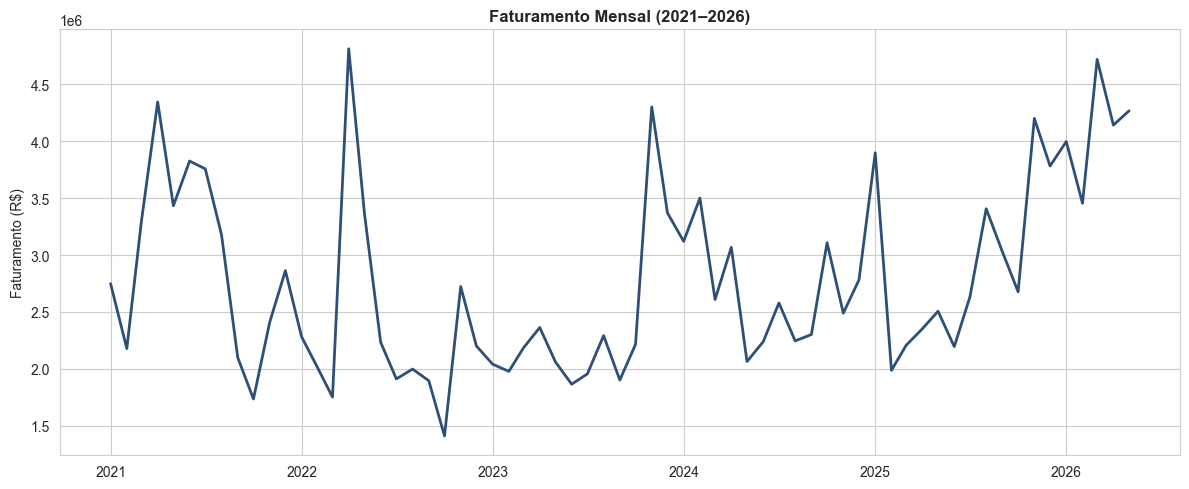

In [5]:
mensal = df.groupby('AnoMes')['Total'].sum()
mensal.index = mensal.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(mensal.index, mensal.values, color=COLOR_MAIN, linewidth=2)
ax.set_title('Faturamento Mensal (2021–2026)')
ax.set_ylabel('Faturamento (R$)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('images/faturamento_mensal.png', dpi=150)
plt.show()

In [6]:
anual = df.groupby('Ano').agg(
    Faturamento=('Total','sum'),
    Pedidos=('Total','count'),
    TicketMedio=('Total','mean')
).round(2)
anual['CrescimentoFaturamento(%)'] = (anual['Faturamento'].pct_change()*100).round(1)
anual

,Faturamento,Pedidos,TicketMedio,CrescimentoFaturamento(%)
Ano,,,,
2021,35866909.40,17345,2067.85,NaN
2022,28596238.97,11988,2385.41,-20.3
2023,28533243.07,11565,2467.21,-0.2
2024,32107108.40,11292,2843.35,12.5
2025,34870621.63,14140,2466.10,8.6
2026,20573276.71,8197,2509.85,-41.0


**Leitura:** o faturamento caiu fortemente em 2022 (-20,3%), ficou estável em 2023, e vem crescendo desde então (+12,5% em 2024 e +8,6% em 2025). Os 5 primeiros meses de 2026 somam R$ 20,6M — se mantido o ritmo, 2026 fecharia como o melhor ano da série. Importante: o número de pedidos vem caindo ano a ano desde 2021, enquanto o ticket médio sobe — ou seja, o crescimento recente de faturamento está puxado por **ticket médio maior**, não por mais pedidos.

### 5.2 Faturamento por Estado

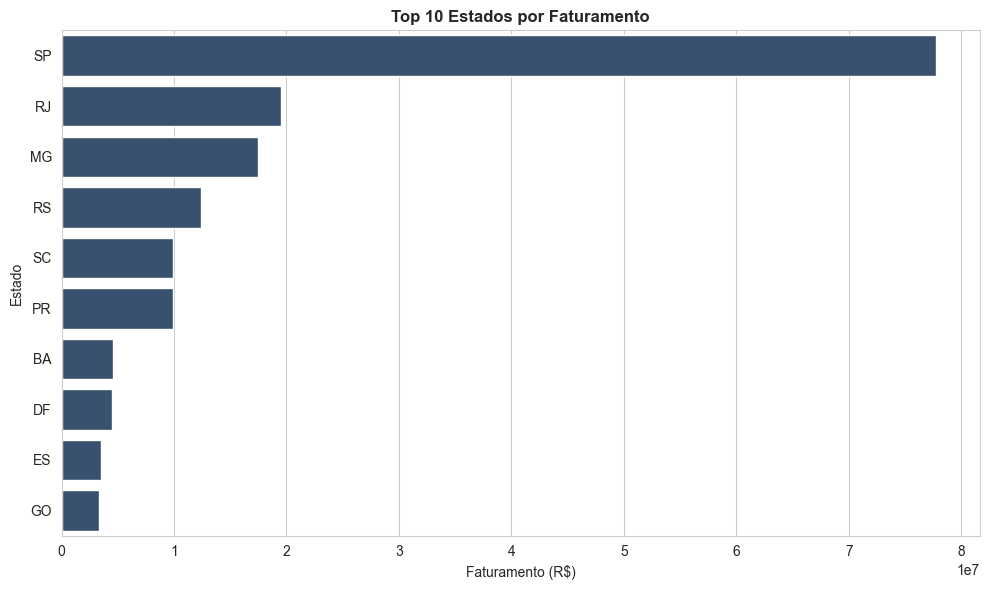

Top 5 estados concentram 76.0% do faturamento


Estado
SP    43.1
RJ    10.8
MG     9.7
RS     6.9
SC     5.5
PR     5.5
BA     2.5
DF     2.5
ES     2.0
GO     1.8
Name: Total, dtype: float64

In [7]:
por_estado = df.groupby('Estado')['Total'].sum().sort_values(ascending=False)
participacao = (por_estado / por_estado.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(10,6))
top10 = por_estado.head(10)
sns.barplot(x=top10.values, y=top10.index, ax=ax, color=COLOR_MAIN)
ax.set_title('Top 10 Estados por Faturamento')
ax.set_xlabel('Faturamento (R$)')
plt.tight_layout()
plt.savefig('images/faturamento_estado.png', dpi=150)
plt.show()

print(f"Top 5 estados concentram {participacao.head(5).sum():.1f}% do faturamento")
participacao.head(10)

**Leitura:** São Paulo concentra **43,1%** de todo o faturamento, sozinho. Os 5 maiores estados (SP, RJ, MG, RS, SC) somam **~76%** das vendas — alta concentração geográfica, o que representa tanto uma força (mercados consolidados) quanto um risco (dependência de poucas regiões).

### 5.3 Sazonalidade — Dia da Semana e Horário

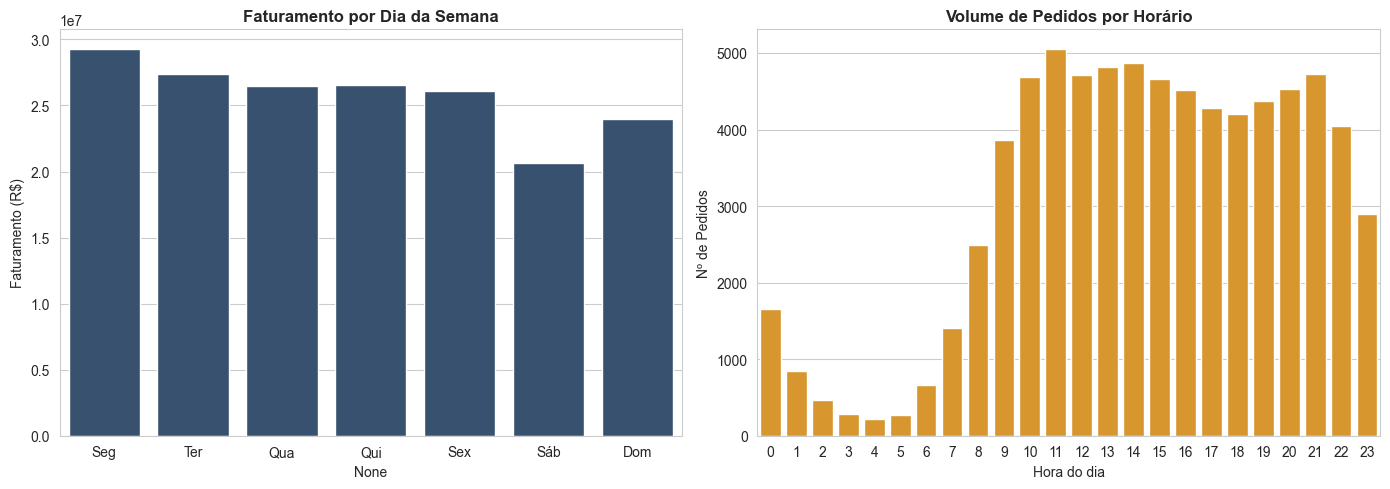

In [8]:
ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
nomes_pt = {'Monday':'Seg','Tuesday':'Ter','Wednesday':'Qua','Thursday':'Qui',
            'Friday':'Sex','Saturday':'Sáb','Sunday':'Dom'}

por_dia = df.groupby('DiaSemana')['Total'].sum().reindex(ordem_dias)
por_dia.index = [nomes_pt[d] for d in por_dia.index]

por_hora = df.groupby('HoraNum')['Total'].count()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x=por_dia.index, y=por_dia.values, ax=axes[0], color=COLOR_MAIN)
axes[0].set_title('Faturamento por Dia da Semana')
axes[0].set_ylabel('Faturamento (R$)')

sns.barplot(x=por_hora.index, y=por_hora.values, ax=axes[1], color=COLOR_ACC)
axes[1].set_title('Volume de Pedidos por Horário')
axes[1].set_ylabel('Nº de Pedidos')
axes[1].set_xlabel('Hora do dia')

plt.tight_layout()
plt.savefig('images/sazonalidade.png', dpi=150)
plt.show()

**Leitura:** o sábado é o dia de menor faturamento (queda de ~25% frente aos dias de semana), enquanto domingo já recupera parte do movimento. O volume de pedidos cresce a partir das 8h, atinge o pico entre 10h e 21h de forma bem distribuída, e cai abruptamente após as 22h.

## 6. Análise Diagnóstica

### 6.1 Hipóteses de Negócio

Para entender **por que** o faturamento sobe ou desce, testamos algumas hipóteses usando a série diária de pedidos.

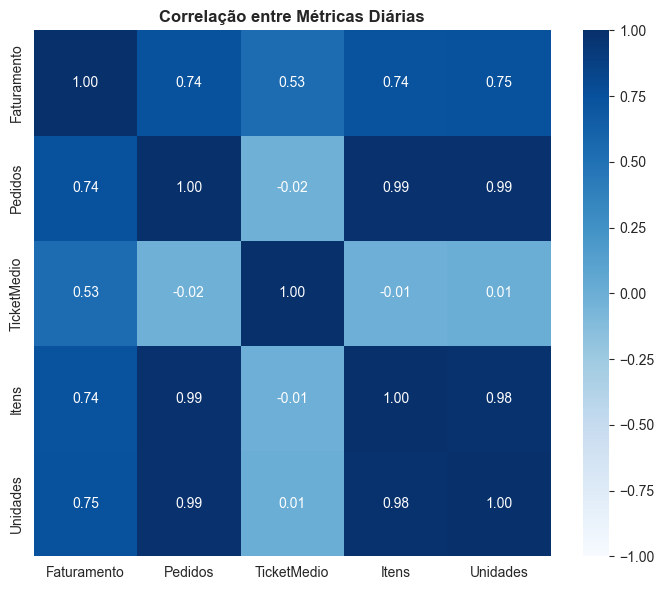

In [9]:
diario = df.groupby('Data').agg(
    Faturamento=('Total','sum'),
    Pedidos=('Total','count'),
    Itens=('Qtd. Itens','sum'),
    Unidades=('Qtd. Unidades','sum')
)
diario['TicketMedio'] = diario['Faturamento'] / diario['Pedidos']

corr = diario[['Faturamento','Pedidos','TicketMedio','Itens','Unidades']].corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlação entre Métricas Diárias')
plt.tight_layout()
plt.savefig('images/correlacao.png', dpi=150)
plt.show()

#### H1. Quanto maior o número de pedidos no dia, maior o faturamento do dia.
**Aceita:** correlação de **0,74** entre pedidos e faturamento diário — forte relação positiva.

#### H2. Quanto maior o ticket médio do dia, maior o faturamento do dia.
**Aceita parcialmente:** correlação de **0,53** — existe relação, mas mais fraca que a do volume de pedidos. O ticket médio sozinho não é o principal motor diário do faturamento.

#### H3. O crescimento de faturamento recente vem do aumento no número de pedidos.
**Rejeitada:** o número de pedidos por ano vem **caindo** desde 2021 (17.345 → ~8.200 nos 5 primeiros meses de 2026, projeção anualizada abaixo do pico), enquanto o faturamento anual está em recuperação. O crescimento recente é explicado pelo **ticket médio**, que subiu de R$ 2.067 (2021) para a faixa de R$ 2.400–2.850 nos anos seguintes — e não pelo volume.

#### H4. O faturamento está concentrado em poucos estados.
**Aceita:** SP isolado responde por 43,1% do faturamento; os 5 maiores estados somam ~76%. Isso é tanto uma oportunidade comercial (mercados maduros) como um risco de concentração.

#### H5. O fim de semana tem desempenho pior que os dias úteis.
**Aceita parcialmente:** sábado é claramente o dia mais fraco; domingo já se aproxima da média da semana.

## 7. Análise Preditiva — Previsão de Faturamento (Junho/2026)

Para prever o faturamento do próximo mês, usamos uma abordagem de decomposição de série temporal em **Sazonalidade × Tendência × Erro**, no nível mensal (a granularidade diária é muito ruidosa para este negócio, dado o volume de pedidos por dia).

**Passos:**
1. Calcular a média móvel centralizada de 12 meses para suavizar a curva de faturamento mensal.
2. Dividir o faturamento real pela média móvel para isolar a sazonalidade (com erro embutido), e tirar a média da sazonalidade por mês do calendário (Jan, Fev, ..., Dez).
3. Desazonalizar o faturamento (Faturamento Real ÷ Sazonalidade do mês).
4. Treinar uma Regressão Linear sobre a série desazonalizada (últimos 24 meses) para capturar a tendência.
5. Prever: `Previsão = Tendência × Sazonalidade do mês`.

In [10]:
mensal_serie = df.groupby('AnoMes')['Total'].sum()
mensal_serie.index = mensal_serie.index.to_timestamp()

# 1) média móvel 12 meses centralizada
ma12 = mensal_serie.rolling(12, center=True, min_periods=6).mean()

# 2) sazonalidade + erro, por mês do calendário
saz_erro = mensal_serie / ma12
saz_por_mes = pd.Series(saz_erro.values, index=mensal_serie.index.month).groupby(level=0).mean()

# 3) desazonalizar
desaz = mensal_serie / mensal_serie.index.month.map(saz_por_mes)
desaz = desaz.dropna()

# 4) tendência (últimos 24 meses)
recente = desaz.tail(24)
X = np.arange(len(recente)).reshape(-1,1)
y = recente.values
modelo = LinearRegression().fit(X, y)

# 5) previsão para o próximo mês (junho/2026)
x_next = np.array([[len(recente)]])
tendencia_jun = modelo.predict(x_next)[0]
saz_jun = saz_por_mes[6]
previsao_jun = tendencia_jun * saz_jun

print(f"Sazonalidade média de Junho: {saz_jun:.3f}")
print(f"Tendência projetada: R$ {tendencia_jun:,.2f}")
print(f"Previsão de faturamento Junho/2026: R$ {previsao_jun:,.2f}")

Sazonalidade média de Junho: 0.922
Tendência projetada: R$ 3,959,681.04
Previsão de faturamento Junho/2026: R$ 3,650,157.08


In [11]:
# Backtest: medir o erro do modelo prevendo os últimos 6 meses conhecidos
resultados = []
for h in range(1, 7):
    treino = desaz.iloc[:-h].tail(24)
    Xt = np.arange(len(treino)).reshape(-1,1)
    yt = treino.values
    m = LinearRegression().fit(Xt, yt)
    tendencia_pred = m.predict(np.array([[len(treino)]]))[0]
    data_alvo = desaz.index[-h]
    pred = tendencia_pred * saz_por_mes[data_alvo.month]
    real = mensal_serie[data_alvo]
    resultados.append((data_alvo.strftime('%Y-%m'), pred, real, abs(pred-real)/real*100))

backtest = pd.DataFrame(resultados, columns=['Mês','Previsto','Real','Erro(%)']).sort_values('Mês')
mape = backtest['Erro(%)'].mean()
backtest

,Mês,Previsto,Real,Erro(%)
5,2025-12,3.234160e+06,3781526.53,14.474751
4,2026-01,3.309772e+06,3995600.95,17.164608
3,2026-02,2.894229e+06,3454586.11,16.220660
2,2026-03,3.375736e+06,4717066.77,28.435704
1,2026-04,4.793896e+06,4140404.81,15.783263
0,2026-05,3.972253e+06,4265618.07,6.877436


In [12]:
print(f"MAPE médio do modelo (últimos 6 meses): {mape:.1f}%")
margem = previsao_jun * mape / 100
print(f"Previsão Junho/2026: R$ {previsao_jun:,.2f}")
print(f"Intervalo esperado (±{mape:.1f}%): R$ {previsao_jun-margem:,.2f} a R$ {previsao_jun+margem:,.2f}")

MAPE médio do modelo (últimos 6 meses): 16.5%
Previsão Junho/2026: R$ 3,650,157.08
Intervalo esperado (±16.5%): R$ 3,048,146.28 a R$ 4,252,167.88


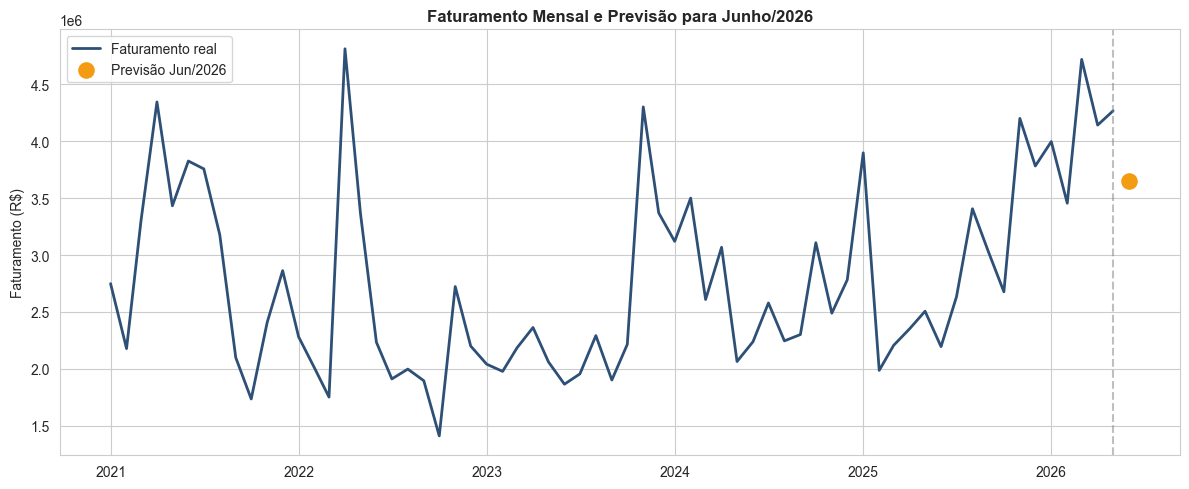

In [13]:
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(mensal_serie.index, mensal_serie.values, label='Faturamento real', color=COLOR_MAIN, linewidth=2)
ax.scatter([mensal_serie.index[-1] + pd.DateOffset(months=1)], [previsao_jun],
           color=COLOR_ACC, s=120, zorder=5, label='Previsão Jun/2026')
ax.axvline(mensal_serie.index[-1], color='gray', linestyle='--', alpha=0.5)
ax.set_title('Faturamento Mensal e Previsão para Junho/2026')
ax.set_ylabel('Faturamento (R$)')
ax.legend()
plt.tight_layout()
plt.savefig('images/previsao.png', dpi=150)
plt.show()

**Resultado:** o modelo aponta um faturamento previsto de aproximadamente **R$ 3,65 milhões** para junho/2026, com um erro médio histórico (MAPE) de cerca de **16,5%** — ou seja, o resultado real deve ficar entre aproximadamente R$ 3,05M e R$ 4,25M.

## 8. Análise Prescritiva — Recomendações

Com base nas análises descritiva e diagnóstica, seguem recomendações práticas para a diretoria:

1. **Atacar a queda no volume de pedidos.** O faturamento recente cresce por ticket médio, não por volume e o volume de pedidos é a variável mais correlacionada ao faturamento diário (0,74). Recuperar o volume de pedidos (marketing, aquisição, recompra) tem potencial de acelerar ainda mais o crescimento.
2. **Reduzir a dependência de São Paulo.** Com 43% do faturamento concentrado em um único estado, investir em campanhas regionais para Sul e Nordeste (hoje com participação ainda baixa) pode diversificar a receita e reduzir o risco de concentração geográfica.
3. **Reforçar o sábado com ações comerciais.** É o dia de pior desempenho relativo, promoções ou frete grátis específicos para sábado podem nivelar o faturamento ao longo da semana.
4. **Aproveitar a janela de pico (10h–21h).** Concentrar comunicação, anúncios pagos e disponibilidade de atendimento nesse intervalo, já que é onde está a maior parte da demanda.
5. **Monitorar o ticket médio como alavanca de curto prazo**, mas sem depender só dele: ele tem menor correlação com o faturamento diário (0,53) que o volume de pedidos, então funciona melhor como complemento, não como motor principal de crescimento.

## 9. Conclusão

A ShopOnline atravessou uma retração em 2022 e está em trajetória de recuperação desde 2024, puxada principalmente pelo aumento do ticket médio — enquanto o volume de pedidos ainda não voltou aos níveis de 2021. O negócio é fortemente concentrado em São Paulo e apresenta sazonalidade clara por dia da semana e horário. A previsão para junho/2026 indica continuidade do crescimento, em torno de **R$ 3,65M** (±16,5%). As recomendações práticas miram especificamente recuperar volume de pedidos e diversificar a base geográfica, que são os pontos de maior risco e maior oportunidade identificados na análise.
